In [1]:
import pandas as pd

file_path = r'D:\Aa中工互联\工作安排\英格索兰\data\原始数据集.xlsx'
df = pd.read_excel(file_path)

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 241919 entries, 0 to 241918
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   时间         241919 non-null  datetime64[ns]
 1   DQ200系统压力  241919 non-null  float64       
 2   AVS系统压力    241919 non-null  float64       
 3   DQ200累积流量  241919 non-null  float64       
 4   AVS累积流量    241919 non-null  float64       
dtypes: datetime64[ns](1), float64(4)
memory usage: 9.2 MB


In [3]:
df.describe()

,时间,DQ200系统压力,AVS系统压力,DQ200累积流量,AVS累积流量
count,241919,241919.000000,241919.00000,2.419190e+05,2.419190e+05
mean,2025-05-07 23:59:59.642855424,6.048795,5.70364,3.303720e+08,5.449789e+07
min,2025-05-01 00:00:00,0.000000,-0.02800,0.000000e+00,0.000000e+00
25%,2025-05-04 11:59:57.500000,5.888000,5.96500,3.295403e+08,5.415043e+07
50%,2025-05-08 00:00:00,5.963000,6.26800,3.302985e+08,5.441212e+07
75%,2025-05-11 12:00:02.500000,6.141000,6.56800,3.311931e+08,5.482350e+07
max,2025-05-15 00:00:00,6.880000,7.33400,3.320285e+08,5.517968e+07
std,NaN,0.254928,1.90051,1.870802e+06,3.602369e+05


In [5]:
# 选择需要的字段
dates = df['时间']
values = df['DQ200累积流量']

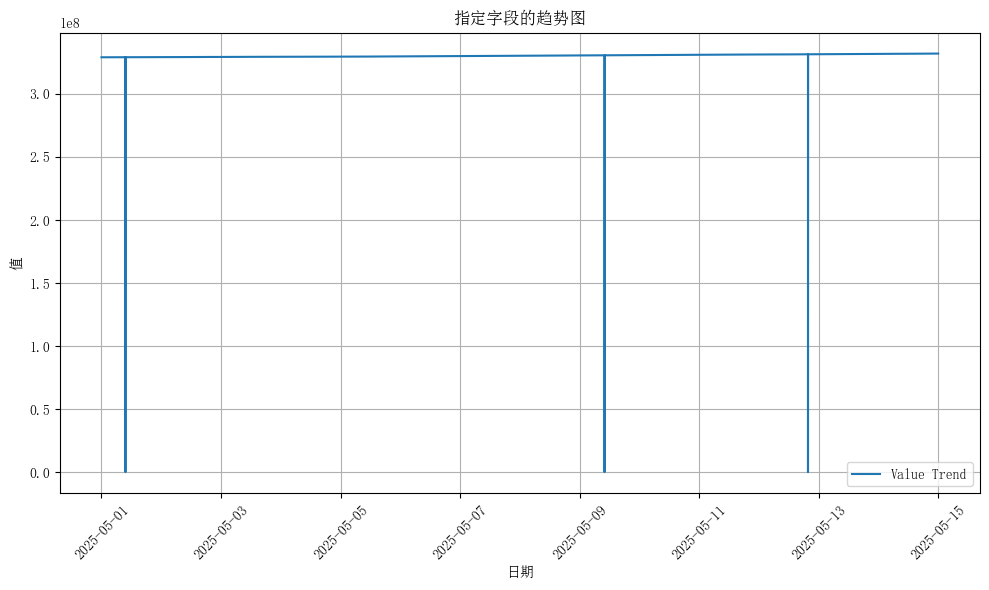

In [6]:
import matplotlib.pyplot as plt

# 创建图形
plt.rcParams['font.sans-serif'] = ['SimSun']       # 设置字体为“宋体”，确保绘制图像不出错
plt.figure(figsize=(10, 6))

# 绘制趋势图
plt.plot(dates, values, label='Value Trend')

# 添加标题和标签
plt.title('指定字段的趋势图')
plt.xlabel('日期')
plt.ylabel('值')
plt.xticks(rotation=45)  # 如果日期标签太多，旋转45度以便更好地显示
plt.grid(True)  # 添加网格以便更清晰地看到趋势
plt.legend()

# 显示图形
plt.tight_layout()  # 自动调整子图参数，使之填充整个图像区域
plt.show()

In [7]:
# 删除Field1和Field2中的0值
data = df[(df['DQ200累积流量'] != 0) & (df['AVS累积流量'] != 0)]

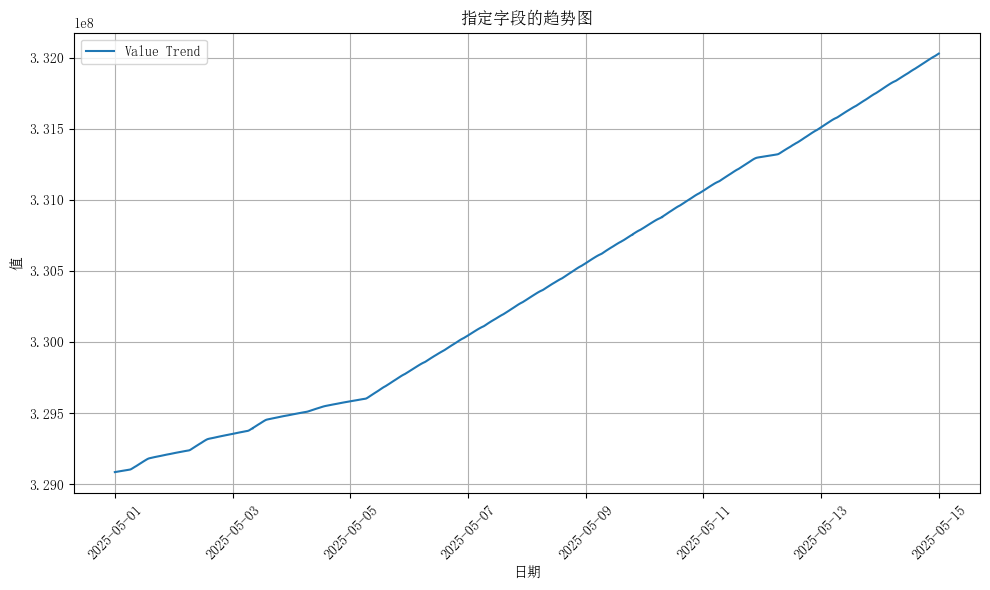

In [8]:
# 选择需要的字段
dates = data['时间']
values = data['DQ200累积流量']

# 创建图形
plt.rcParams['font.sans-serif'] = ['SimSun']       # 设置字体为“宋体”，确保绘制图像不出错
plt.figure(figsize=(10, 6))

# 绘制趋势图
plt.plot(dates, values, label='Value Trend')

# 添加标题和标签
plt.title('指定字段的趋势图')
plt.xlabel('日期')
plt.ylabel('值')
plt.xticks(rotation=45)  # 如果日期标签太多，旋转45度以便更好地显示
plt.grid(True)  # 添加网格以便更清晰地看到趋势
plt.legend()

# 显示图形
plt.tight_layout()  # 自动调整子图参数，使之填充整个图像区域
plt.show()

In [9]:
df.columns

Index(['时间', 'DQ200系统压力', 'AVS系统压力', 'DQ200累积流量', 'AVS累积流量'], dtype='object')

# 箱体图

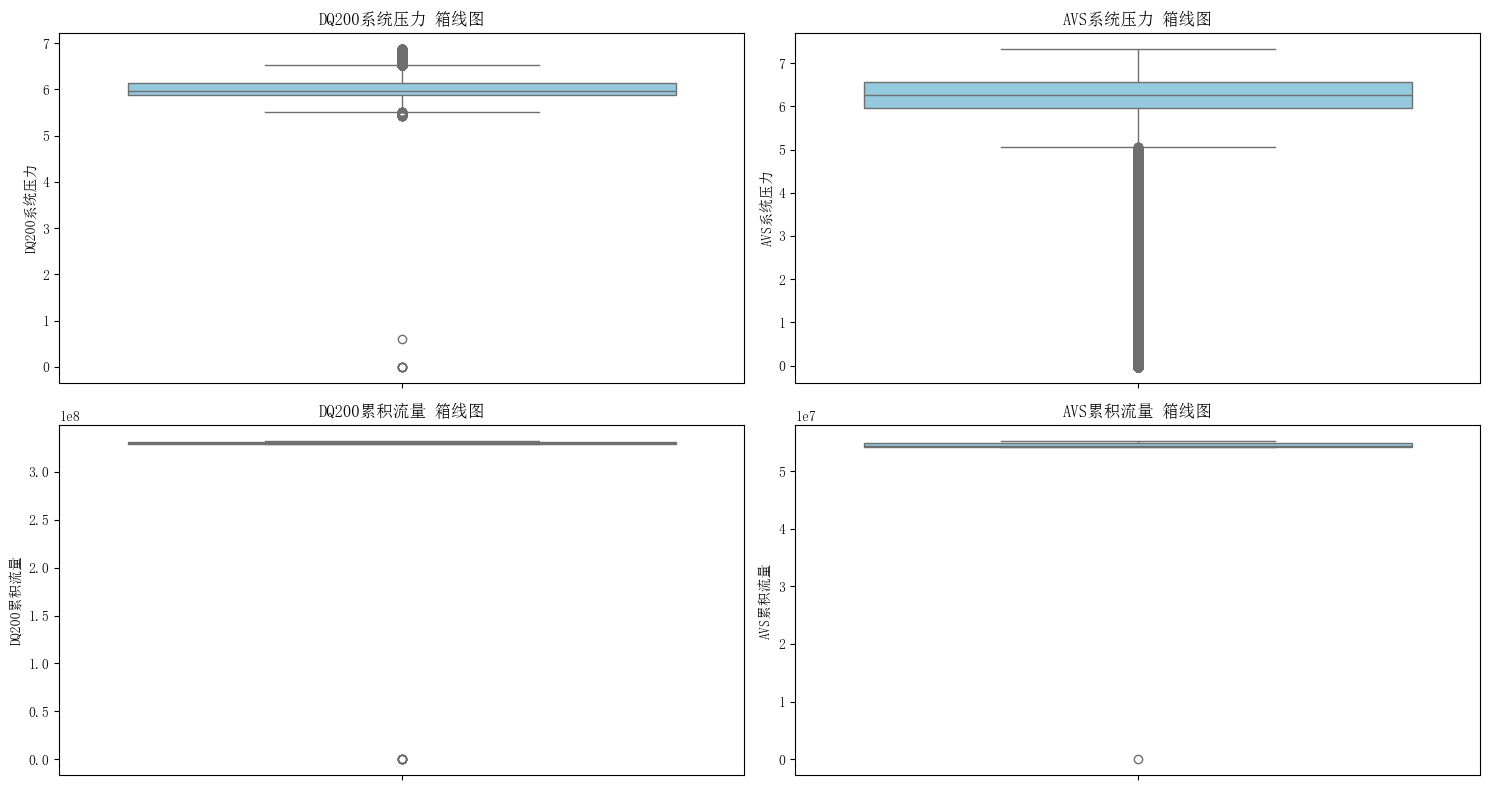

In [10]:
import seaborn as sns

numeric_cols = ['DQ200系统压力', 'AVS系统压力', 'DQ200累积流量', 'AVS累积流量']

plt.figure(figsize=(15, 8))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(f'{col} 箱线图')
plt.tight_layout()
plt.show()

# IQR方法处理异常值

In [11]:
# --------------------- 2. IQR异常值处理 ---------------------
def treat_outliers_iqr(df, col):
    """
    用IQR方法处理指定列的异常值
    策略：将超出范围的值替换为边界值
    """
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    # 记录异常值数量
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"{col} 异常值数量: {len(outliers)}")
    
    # 替换异常值为边界值
    df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)
    return df

# 创建处理后的副本（保留原始数据）
df_clean = df.copy()

# 对每个数值列应用处理
for col in numeric_cols:
    df_clean = treat_outliers_iqr(df_clean, col)

# --------------------- 3. 对比处理效果 ---------------------
print("\n处理后的统计摘要:")
print(df_clean[numeric_cols].describe())

DQ200系统压力 异常值数量: 26278
AVS系统压力 异常值数量: 25019
DQ200累积流量 异常值数量: 6
AVS累积流量 异常值数量: 1

处理后的统计摘要:
           DQ200系统压力        AVS系统压力     DQ200累积流量       AVS累积流量
count  241919.000000  241919.000000  2.419190e+05  2.419190e+05
mean        6.039998       6.201505  3.303801e+08  5.449811e+07
std         0.233354       0.494142  8.905602e+05  3.427845e+05
min         5.508500       5.060500  3.270612e+08  5.314081e+07
25%         5.888000       5.965000  3.295403e+08  5.415043e+07
50%         5.963000       6.268000  3.302985e+08  5.441212e+07
75%         6.141000       6.568000  3.311931e+08  5.482350e+07
max         6.520500       7.334000  3.320285e+08  5.517968e+07


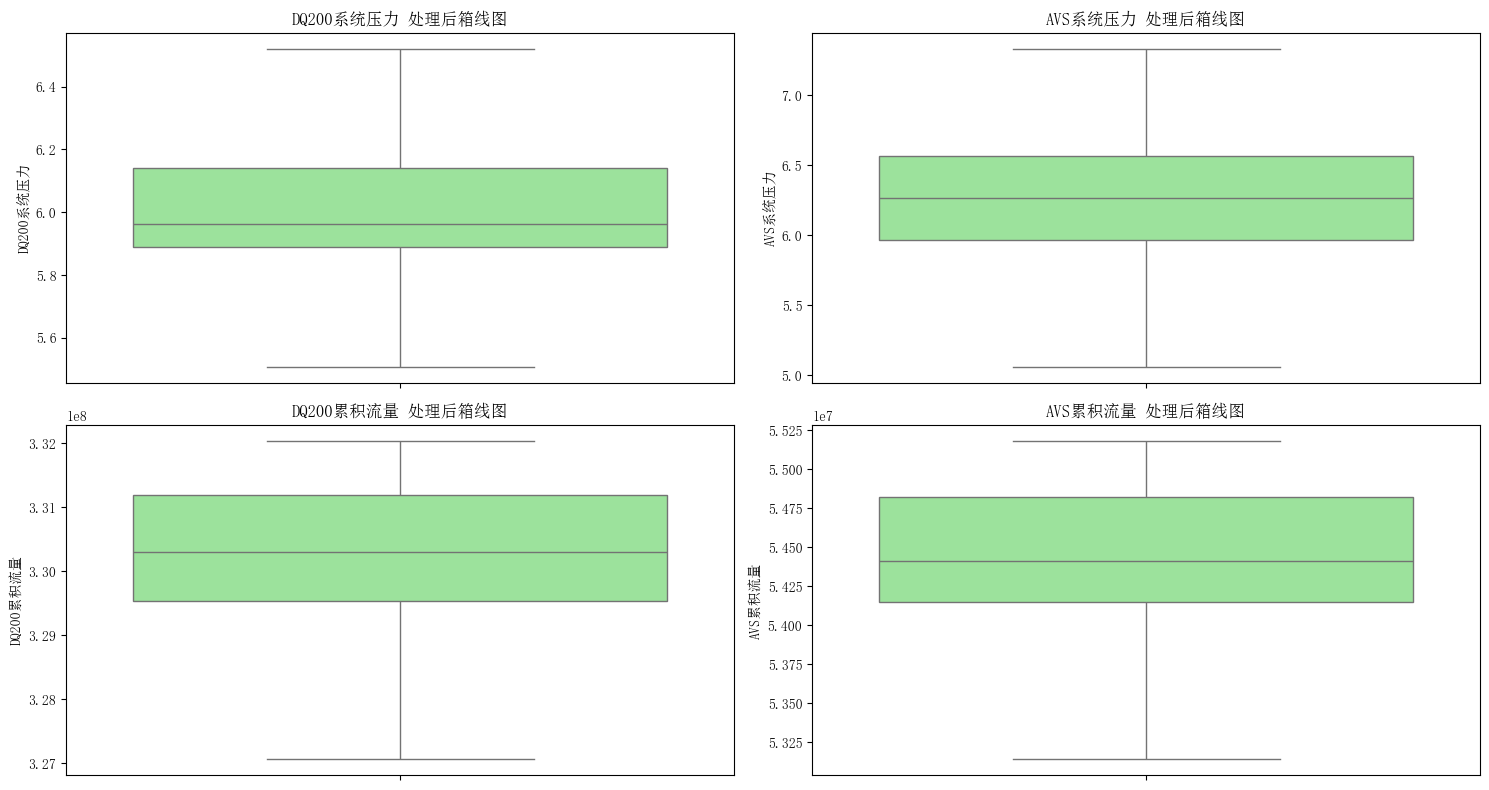

In [12]:
# 可视化处理后的箱线图
plt.figure(figsize=(15, 8))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(y=df_clean[col], color='lightgreen')
    plt.title(f'{col} 处理后箱线图')
plt.tight_layout()
plt.show()

IQR处理逻辑：

定义treat_outliers_iqr()函数：

计算25%（Q1）和75%（Q3）分位数

计算IQR = Q3 - Q1

异常值范围：< Q1-1.5IQR 或 > Q3+1.5IQR

使用clip()方法将超出范围的值替换为边界值

创建副本df_clean保留原始数据

In [13]:
# 需要安装openpyxl：pip install openpyxl
df_clean.to_excel('cleaned_data.xlsx', index=False)